<div style="font-family: 'Roboto Mono'; color: #00008B; font-size: 25px; line-height: 1;">
    
>                        **Zee Recommender Systems**

Problem Statement : 

Create a Recommender System to show personalized movie recommendations based on :
> 1. Ratings given by a user
>    
> 2. Other users similar to them
>
in order to improve user experience.

Goal:

> Unlike classification or regression, the goal is to suggest a ranked list of movies to users based on historical data, with a vast scale of users and movies.

In [4]:
# loading necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [5]:
# creating movies df
columns = ['MovieID', 'Title', 'Genres']

movies = pd.read_csv(
    'zee-movies.dat', 
    sep='::', 
    names=columns, 
    encoding='ISO-8859-1', 
    engine='python'
)

In [6]:
movies.isnull().sum()

MovieID    0
Title      0
Genres     0
dtype: int64

In [7]:
movies.duplicated().sum()

np.int64(0)

In [8]:
movies.head()

,MovieID,Title,Genres
0,Movie ID,Title,Genres
1,1,Toy Story (1995),Animation|Children's|Comedy
2,2,Jumanji (1995),Adventure|Children's|Fantasy
3,3,Grumpier Old Men (1995),Comedy|Romance
4,4,Waiting to Exhale (1995),Comedy|Drama


In [9]:
movies.info(memory_usage=False,show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3884 entries, 0 to 3883
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   MovieID  object
 1   Title    object
 2   Genres   object
dtypes: object(3)

•	Titles are identical to titles provided by the IMDB (including year of release)

Genres are pipe-separated and are selected from the following genres:

> Action

> Adventure

> Animation

> Children's

> Comedy

> Crime

> Documentary

> Drama

> Fantasy

> Film-Noir

> Horror

> Musical

> Mystery

> Romance

> Sci-Fi

> Thriller

> War

> Western

In [10]:
# creating ratings df
columns = ['UserID', 'MovieID', 'Rating', 'Timestamp']

ratings = pd.read_csv(
    'zee-ratings.dat', 
    sep='::', 
    names=columns, 
    encoding='ISO-8859-1', 
    engine='python'
)

In [11]:
ratings.isnull().sum()

UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

In [12]:
ratings.duplicated().sum()

np.int64(0)

In [13]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,UserID,MovieID,Rating,Timestamp
1,1,1193,5,978300760
2,1,661,3,978302109
3,1,914,3,978301968
4,1,3408,4,978300275


In [14]:
ratings.info(memory_usage=False,show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000210 entries, 0 to 1000209
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   UserID     object
 1   MovieID    object
 2   Rating     object
 3   Timestamp  object
dtypes: object(4)

> 	UserIDs range between 1 and 6040

> 	MovieIDs range between 1 and 3952

> 	Ratings are made on a 5-star scale (whole-star ratings only)

> 	Timestamp is represented in seconds

In [15]:
# creating users df
columns = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']

users = pd.read_csv(
    'zee-users.dat', 
    sep='::', 
    names=columns, 
    encoding='ISO-8859-1', 
    engine='python'
)

In [16]:
users.isnull().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

In [17]:
users.duplicated().sum()

np.int64(0)

In [18]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,UserID,Gender,Age,Occupation,Zip-code
1,1,F,1,10,48067
2,2,M,56,16,70072
3,3,M,25,15,55117
4,4,M,45,7,02460


In [19]:
users.info(memory_usage=False,show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6041 entries, 0 to 6040
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   UserID      object
 1   Gender      object
 2   Age         object
 3   Occupation  object
 4   Zip-code    object
dtypes: object(5)

All demographic information is provided voluntarily by the users and is not checked for accuracy.

Only users who have provided some demographic information are included in this data set.

Gender is denoted by a "M" for male and "F" for female

Age is chosen from the following ranges:

> 1: "Under 18"

> 18: "18-24"

> 25: "25-34"

> 35: "35-44"

> 45: "45-49"

> 50: "50-55"

> 56: "56+"

Occupation is chosen from the following choices:

> 0: "other" or not specified

> 1: "academic/educator"

> 2: "artist"

> 3: "clerical/admin"

> 4: "college/grad student"

> 5: "customer service"

> 6: "doctor/health care"

> 7: "executive/managerial"

> 8: "farmer"

> 9: "homemaker"

> 10: "K-12 student"

> 11: "lawyer"

> 12: "programmer"

> 13: "retired"

> 14: "sales/marketing"

> 15: "scientist"

> 16: "self-employed"

> 17: "technician/engineer"

> 18: "tradesman/craftsman"

> 19: "unemployed"

> 20: "writer"

In [20]:
# Merge users,ratings, then merge movies
df_merged = pd.merge(users, ratings, on='UserID', how='left')

# removing the 0 duplicate index and resetting the index
df_merged_cleaned = pd.merge(df_merged, movies, on='MovieID', how='left').drop(0).reset_index(drop=True) 

In [21]:
df_merged_cleaned.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Rating,Timestamp,Title,Genres
0,1,F,1,10,48067,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,F,1,10,48067,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,F,1,10,48067,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,F,1,10,48067,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,F,1,10,48067,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [22]:
df_merged_cleaned.isnull().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
MovieID       0
Rating        0
Timestamp     0
Title         0
Genres        0
dtype: int64

In [23]:
# Define the new column order sequence
new_order = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code', 'MovieID', 'Title', 'Genres', 'Rating', 'Timestamp']

# Reindex the DataFrame columns
df_new_order = df_merged_cleaned[new_order]

# this is a denormalized data
df_denormalized = df_new_order.drop('Timestamp',axis=1)

In [24]:
df_denormalized.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating
0,1,F,1,10,48067,1193,One Flew Over the Cuckoo's Nest (1975),Drama,5
1,1,F,1,10,48067,661,James and the Giant Peach (1996),Animation|Children's|Musical,3
2,1,F,1,10,48067,914,My Fair Lady (1964),Musical|Romance,3
3,1,F,1,10,48067,3408,Erin Brockovich (2000),Drama,4
4,1,F,1,10,48067,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,5


In [25]:
# feature extraction and cleaning
df_denormalized['Release_year'] = df_denormalized['Title'].str.extract(r'\((\d{4})\)')
df_denormalized['Title'] =  df_denormalized['Title'].str.extract(r'^(.*?)\s*\(') # removing year from titles

In [26]:
df_denormalized.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Release_year
0,1,F,1,10,48067,1193,One Flew Over the Cuckoo's Nest,Drama,5,1975
1,1,F,1,10,48067,661,James and the Giant Peach,Animation|Children's|Musical,3,1996
2,1,F,1,10,48067,914,My Fair Lady,Musical|Romance,3,1964
3,1,F,1,10,48067,3408,Erin Brockovich,Drama,4,2000
4,1,F,1,10,48067,2355,"Bug's Life, A",Animation|Children's|Comedy,5,1998


In [27]:
df_denormalized.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   UserID        1000209 non-null  object
 1   Gender        1000209 non-null  object
 2   Age           1000209 non-null  object
 3   Occupation    1000209 non-null  object
 4   Zip-code      1000209 non-null  object
 5   MovieID       1000209 non-null  object
 6   Title         1000209 non-null  object
 7   Genres        1000209 non-null  object
 8   Rating        1000209 non-null  object
 9   Release_year  1000209 non-null  object
dtypes: object(10)

**Comments:**

> 1. A highly **denormalized** pandas DataFrame containing movie rating logs with exactly 1,000,209 entries and 10 columns
>
> 2. Every single column is currently casted as a **generic object data type**, which means pandas is treating numbers (like Age, Rating, Release_year) and IDs as strings or mixed types.
>
> 3. Before doing any serious analysis or modeling, we should optimize our data types (Dtypes) to free up memory and enable math operations

In [28]:
# copying to a new dataframe for EDA
df_eda = df_denormalized.copy()

In [29]:
# 1. Convert numeric columns from 'object' to integers/floats
df_eda['Rating'] = pd.to_numeric(df_eda['Rating'], errors='coerce')
df_eda['Release_year'] = pd.to_numeric(df_eda['Release_year'], errors='coerce').astype('int64')

# 2. Convert categorical flags to save memory
df_eda['Gender'] = df_eda['Gender'].astype('category')

# 3. Ensure IDs are consistently typed (either string or integer depending on your data)
df_eda['UserID'] = df_eda['UserID'].astype(str)
df_eda['MovieID'] = df_eda['MovieID'].astype(str)

In [30]:
# checking the shape of the data
df_eda.shape

(1000209, 10)

In [31]:
# checking for nulls
df_eda.isnull().sum()

UserID          0
Gender          0
Age             0
Occupation      0
Zip-code        0
MovieID         0
Title           0
Genres          0
Rating          0
Release_year    0
dtype: int64

In [32]:
# checking for duplicate rows
df_eda.duplicated().sum()

np.int64(0)

In [33]:
# checking for unique values in each column
for col in df_eda:
    print(f'{col}: {df_eda[col].nunique()}')
    print("- "* 10)

UserID: 6040
- - - - - - - - - - 
Gender: 2
- - - - - - - - - - 
Age: 7
- - - - - - - - - - 
Occupation: 21
- - - - - - - - - - 
Zip-code: 3439
- - - - - - - - - - 
MovieID: 3706
- - - - - - - - - - 
Title: 3657
- - - - - - - - - - 
Genres: 301
- - - - - - - - - - 
Rating: 5
- - - - - - - - - - 
Release_year: 81
- - - - - - - - - - 


**Comments:**

> 1. There are 6040 unique users in the dataset
>
> 2. 7 Age groups
>
> 3. 21 Occupation titles
>
> 4. 3439 regions/zip-codes
>
> 5. There are a total of 3706 movies and 3657 titles in this dataset. This difference is may be due to re-release/re-make of the same movie in a different year under the same title.


In [34]:
# checking for data inconsistency

# Group by Title and Release_year, then count unique MovieIDs
id_groups = df_eda.groupby(['Title', 'Release_year'])['MovieID'].nunique()

# Count how many combinations have MORE than 1 unique MovieID
true_inconsistencies = (id_groups.values > 1).sum()
print(f"Number of data inconsistencies: {true_inconsistencies}")

Number of data inconsistencies: 0


In [35]:
# 1. Confirming movies with the same title have a different release year 
title_groups = df_eda.groupby(['Title'])['Release_year'].nunique()
(title_groups.values>1).sum()

np.int64(44)

> This confirms our earlier assumption that every duplicate title is just a normal remake from a different year!

In [36]:
df_eda.info(memory_usage=False,show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column        Dtype   
---  ------        -----   
 0   UserID        object  
 1   Gender        category
 2   Age           object  
 3   Occupation    object  
 4   Zip-code      object  
 5   MovieID       object  
 6   Title         object  
 7   Genres        object  
 8   Rating        int64   
 9   Release_year  int64   
dtypes: category(1), int64(2), object(7)

In [37]:
df_eda.isnull().sum()

UserID          0
Gender          0
Age             0
Occupation      0
Zip-code        0
MovieID         0
Title           0
Genres          0
Rating          0
Release_year    0
dtype: int64

**Univariate Analysis**

**Age Groups**

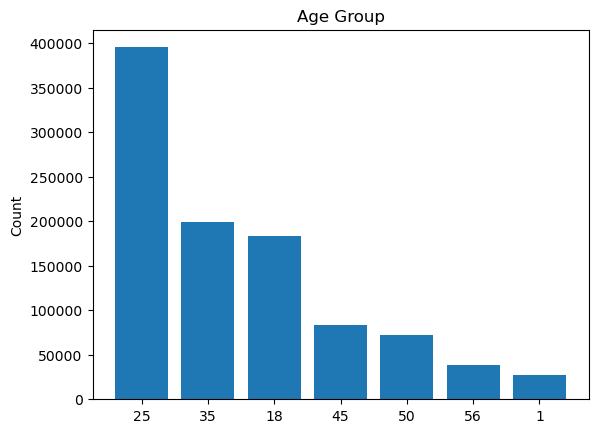

In [38]:
plt.bar(x=df_eda['Age'].value_counts().index,height=df_eda['Age'].value_counts().values)
plt.title("Age Group")
plt.ylabel("Count")
plt.show()

> Age group 25(25-34 yrs old) are the main customer base of Zee platform

**Gender**

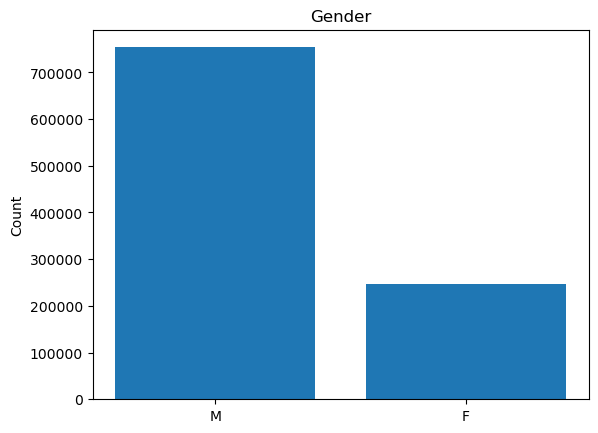

In [39]:
plt.bar(x=df_eda['Gender'].value_counts().index,height=df_eda['Gender'].value_counts().values)
plt.title("Gender")
plt.ylabel("Count")
plt.show()

> 3/4 th of the customer base are males

**Occupation**

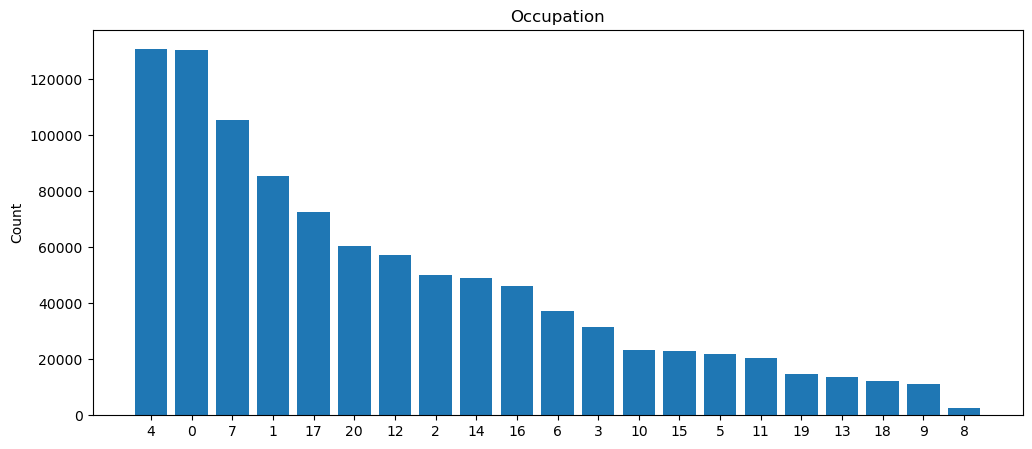

In [40]:
plt.figure(figsize=(12,5))
plt.bar(x=df_eda['Occupation'].value_counts().index,height=df_eda['Occupation'].value_counts().values)
plt.title("Occupation")
plt.ylabel("Count")
plt.show()

> 4: "college/grad student"

> 0: "other" or not specified

> 7: "executive/managerial"

> 1: "academic/educator"

**Rating**

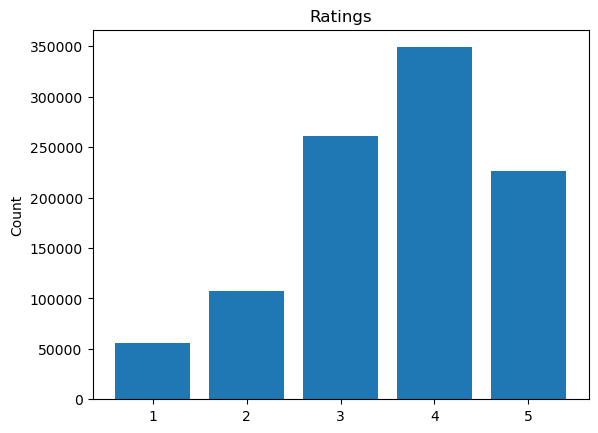

In [41]:
plt.bar(x=df_eda['Rating'].value_counts().index,height=df_eda['Rating'].value_counts().values)
plt.title("Ratings")
plt.ylabel("Count")
plt.show()

> Most of the movies got the rating of 4 and then 3 & 5
>
> Around 150000 movies got ratings of 1-2 indicating that people are genuinely rating the movies they dislike

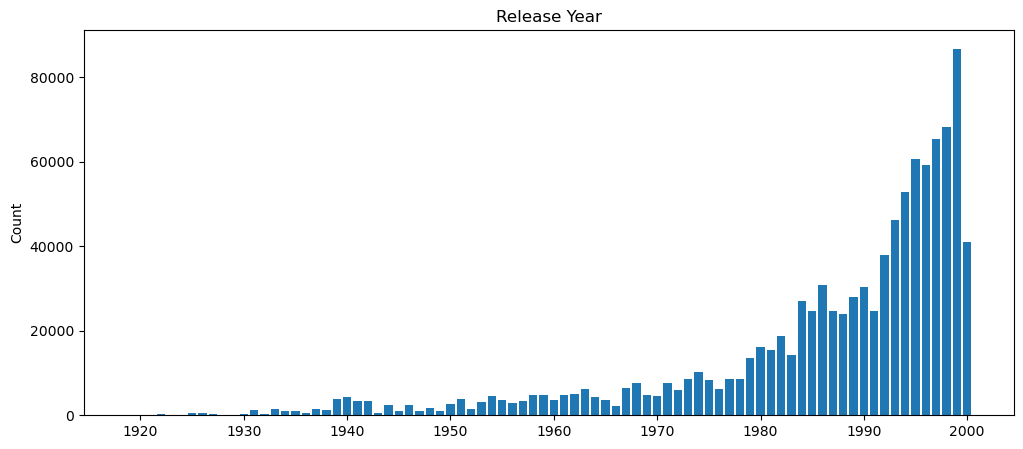

In [42]:
plt.figure(figsize=(12,5))
plt.bar(x=df_eda['Release_year'].value_counts().index,height=df_eda['Release_year'].value_counts().values)
plt.title("Release Year")
plt.ylabel("Count")
plt.show()

**Top10 users**

In [43]:
user_max_viewership = df_eda.groupby('UserID')['MovieID'].count()
user_max_viewership.nlargest(5)

UserID
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
Name: MovieID, dtype: int64

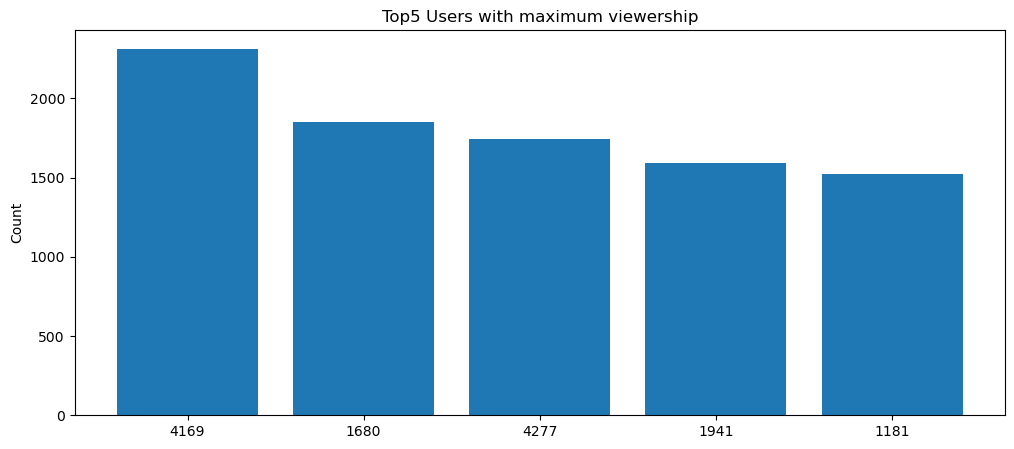

In [44]:
plt.figure(figsize=(12,5))
plt.bar(x=user_max_viewership.nlargest(5).index,height=user_max_viewership.nlargest(5).values)
plt.title("Top5 Users with maximum viewership")
plt.ylabel("Count")
plt.show()

In [45]:
# Feature Engineering
df_eda['Average_Rating'] = df_eda.groupby('MovieID')['Rating'].transform('mean')
df_eda['No_of_Ratings'] = df_eda.groupby('MovieID')['Rating'].transform('count')

In [46]:
df_eda.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Release_year,Average_Rating,No_of_Ratings
0,1,F,1,10,48067,1193,One Flew Over the Cuckoo's Nest,Drama,5,1975,4.390725,1725
1,1,F,1,10,48067,661,James and the Giant Peach,Animation|Children's|Musical,3,1996,3.464762,525
2,1,F,1,10,48067,914,My Fair Lady,Musical|Romance,3,1964,4.154088,636
3,1,F,1,10,48067,3408,Erin Brockovich,Drama,4,2000,3.863878,1315
4,1,F,1,10,48067,2355,"Bug's Life, A",Animation|Children's|Comedy,5,1998,3.854375,1703


**Top 5 Movies with largest number of ratings**

In [47]:
# 1. Keep only unique movies
unique_movies = df_eda.drop_duplicates(subset=['MovieID'])

# 2. Get the top 5 highest-rated unique movies
Total_ratings_Top5 = unique_movies.nlargest(5, 'No_of_Ratings')

In [48]:
Total_ratings_Top5

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Release_year,Average_Rating,No_of_Ratings
105,2,M,56,16,70072,2858,American Beauty,Comedy|Drama,4,1999,4.317386,3428
44,1,F,1,10,48067,260,Star Wars: Episode IV - A New Hope,Action|Adventure|Fantasy|Sci-Fi,4,1977,4.453694,2991
127,2,M,56,16,70072,1196,Star Wars: Episode V - The Empire Strikes Back,Action|Adventure|Drama|Sci-Fi|War,5,1980,4.292977,2990
64,2,M,56,16,70072,1210,Star Wars: Episode VI - Return of the Jedi,Action|Adventure|Romance|Sci-Fi|War,4,1983,4.022893,2883
115,2,M,56,16,70072,480,Jurassic Park,Action|Adventure|Sci-Fi,5,1993,3.763847,2672


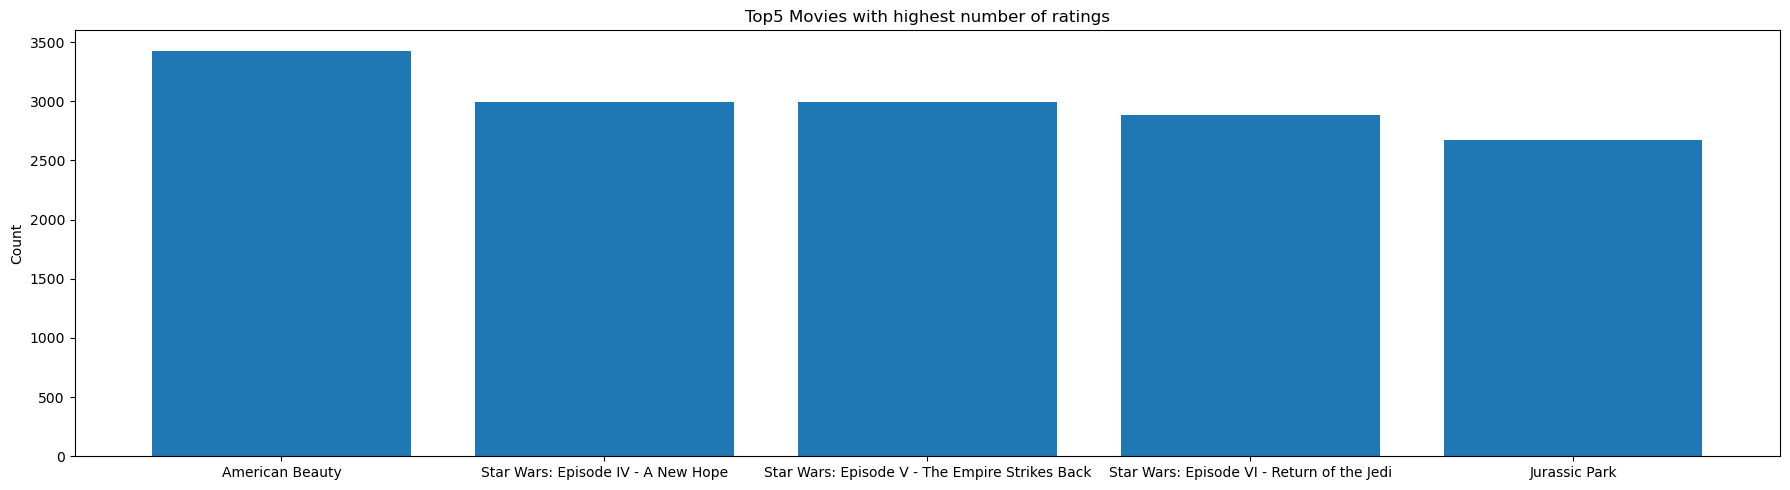

In [49]:
plt.figure(figsize=(18,5))
plt.bar(x=Total_ratings_Top5['Title'],height=Total_ratings_Top5['No_of_Ratings'])
plt.title("Top5 Movies with highest number of ratings")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Top 5 Movies with highest average rating**

In [50]:
# 1. Keep only unique movies
unique_movies = df_eda.drop_duplicates(subset=['MovieID'])

# 2. Get the top 5 highest-rated unique movies
Average_ratings_Top5 = unique_movies.nlargest(5, 'Average_Rating')

In [51]:
Average_ratings_Top5

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Release_year,Average_Rating,No_of_Ratings
6448,46,M,18,19,75602,3280,"Baby, The",Horror,5,1973,5.0,1
19836,149,M,25,1,29205,787,"Gate of Heavenly Peace, The",Documentary,5,1995,5.0,3
322947,1915,M,50,13,01938,989,Schlafes Bruder,Drama,5,1995,5.0,1
465274,2869,M,50,17,07650,1830,Follow the Bitch,Comedy,5,1998,5.0,1
467956,2885,F,18,1,80302,3881,Bittersweet Motel,Documentary,5,2000,5.0,1


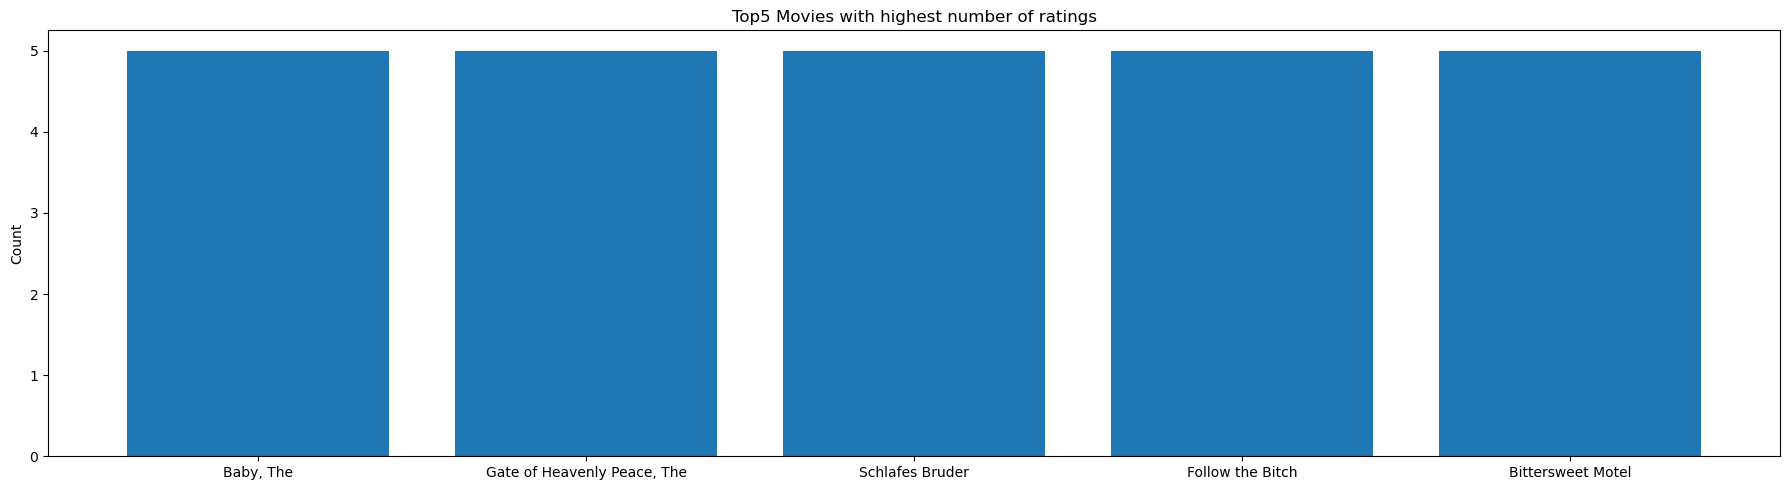

In [52]:
plt.figure(figsize=(18,5))
plt.bar(x=Average_ratings_Top5['Title'],height=Average_ratings_Top5['Average_Rating'])
plt.title("Top5 Movies with highest number of ratings")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [53]:
# Group by movie and calculate both count and mean at once
movie_stats = (df_eda.groupby('MovieID')['Rating']
               .agg(No_of_Ratings='count', Average_Rating='mean')
               .reset_index())
movie_stats

,MovieID,No_of_Ratings,Average_Rating
0,1,2077,4.146846
1,10,888,3.540541
2,100,128,3.062500
3,1000,20,3.050000
4,1002,8,4.250000
...,...,...,...
3701,994,450,4.095556
3702,996,256,2.906250
3703,997,28,3.357143
3704,998,93,3.010753


In [54]:
# 1. Create the pivot table and fill NaN values with 0
movie_pivot = df_eda.pivot_table(
    index='Title',        # Rows will be Movie Titles
    columns='UserID',     # Columns will be User IDs
    values='Rating',      # Intersections will be the ratings
    fill_value=0          # Imputes all NaN values with 0 instantly
)

In [55]:
movie_pivot

UserID,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Night Mother,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"'burbs, The",0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...And Justice for All,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zero Effect,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zero Kelvin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Item-based Recommendations**

> **1. Pearson Correlation**

> Running .T.corr() on a 3,657 × 6,040 matrix requires over 6.4 million vector dot products. Calculating this upfront takes a lot of time and wastes memory, especially since we only need the recommendations for one movie at a time.

> Instead of calculating the correlation for the entire database up front, we can optimize this by calculating the correlation on-the-fly for only the single target movie.

In [56]:
def get_optimized_recommendations(movie_name, pivot_df, top_n=5):
    
    # 1. Check if the movie exists in the pivot table rows
    if movie_name not in pivot_df.index:
        return f"Error: '{movie_name}' not found in the database."
    
    # 2. Extract the rating vector for the target movie
    target_movie_ratings = pivot_df.loc[movie_name]
    
    # 3. Calculate correlation only between this movie and all other columns (movies)
    # We transpose the pivot table inline using .T so columns are movies
    correlations = pivot_df.T.corrwith(target_movie_ratings, method='pearson')
    
    # 4. Clean up: remove the target movie, drop any NaNs, and get the top N
    recommendations = (correlations
                       .drop(index=movie_name)
                       .dropna()
                       .sort_values(ascending=False)
                       .head(top_n)
                       .reset_index())
    
    recommendations.columns = ['Recommended Movie', 'Pearson Correlation']
    return recommendations

# --- Execution ---
user_input = input("Enter a movie name: ")  # e.g., "Toy Story (1995)"
recommendations_df = get_optimized_recommendations(user_input, movie_pivot, top_n=5)
print(recommendations_df)


Enter a movie name:  Toy Story


  Recommended Movie  Pearson Correlation
0       Toy Story 2             0.487370
1           Aladdin             0.470753
2    Lion King, The             0.411131
3     Groundhog Day             0.407547
4     Bug's Life, A             0.402679


> **2. Cosine Similarity**

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(movie_pivot.T)
user_sim_df = pd.DataFrame(
    user_similarity, 
    index=movie_pivot.T.index, 
    columns=movie_pivot.T.index
)

In [59]:
user_sim_df.head()

UserID,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.254736,0.123967,0.207800,0.139112,0.110320,0.121384,0.180073,0.103137,0.052816,...,0.079367,0.038048,0.032136,0.067631,0.070052,0.035731,0.170184,0.159267,0.119356,0.122391
10,0.254736,1.000000,0.259052,0.279838,0.158108,0.112659,0.141661,0.431184,0.193049,0.102253,...,0.154060,0.185809,0.083548,0.125607,0.118288,0.146217,0.304110,0.165321,0.133022,0.247883
100,0.123967,0.259052,1.000000,0.306067,0.075625,0.110450,0.358686,0.237292,0.171609,0.099147,...,0.098235,0.097953,0.065152,0.178664,0.271311,0.033754,0.344290,0.204302,0.113522,0.306937
1000,0.207800,0.279838,0.306067,1.000000,0.098971,0.047677,0.201722,0.355619,0.323584,0.130702,...,0.170100,0.076779,0.000000,0.200343,0.380741,0.044404,0.330748,0.172803,0.098456,0.250564
1001,0.139112,0.158108,0.075625,0.098971,1.000000,0.164611,0.053807,0.151705,0.137387,0.134512,...,0.146055,0.026852,0.096868,0.119433,0.092099,0.109539,0.221792,0.103104,0.269555,0.178137


In [61]:
item_similarity = cosine_similarity(movie_pivot)

# 3. Create the DataFrame using .index of the slice (which contains the 5 movie names)
item_sim_df = pd.DataFrame(
    item_similarity, 
    index=movie_pivot.index, 
    columns=movie_pivot.index
)

In [62]:
item_sim_df.head()

Title,"$1,000,000 Duck",'Night Mother,'Til There Was You,"'burbs, The",...And Justice for All,1-900,10 Things I Hate About You,101 Dalmatians,12 Angry Men,"13th Warrior, The",...,"Young Poisoner's Handbook, The",Young Sherlock Holmes,Young and Innocent,Your Friends and Neighbors,Zachariah,"Zed & Two Noughts, A",Zero Effect,Zero Kelvin,Zeus and Roxanne,eXistenZ
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck",1.000000,0.072357,0.037011,0.079291,0.060838,0.00000,0.058619,0.189843,0.094785,0.058418,...,0.038725,0.076474,0.000000,0.044074,0.0,0.045280,0.039395,0.000000,0.120242,0.027003
'Night Mother,0.072357,1.000000,0.115290,0.115545,0.159526,0.00000,0.076798,0.137135,0.111413,0.046135,...,0.053010,0.087828,0.063758,0.135962,0.0,0.091150,0.074787,0.000000,0.000000,0.077807
'Til There Was You,0.037011,0.115290,1.000000,0.098756,0.066301,0.08025,0.127895,0.128523,0.079115,0.066598,...,0.029200,0.062893,0.000000,0.079187,0.0,0.022594,0.079261,0.000000,0.047526,0.063284
"'burbs, The",0.079291,0.115545,0.098756,1.000000,0.143620,0.00000,0.192191,0.250140,0.170719,0.197808,...,0.113386,0.207897,0.019962,0.138064,0.0,0.055704,0.161174,0.000000,0.033567,0.110525
...And Justice for All,0.060838,0.159526,0.066301,0.143620,1.000000,0.00000,0.075093,0.178928,0.205486,0.122431,...,0.089998,0.153006,0.067009,0.109029,0.0,0.086080,0.110867,0.074317,0.000000,0.111040


In [63]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def get_top_5_recommendations(movie_pivot, target_item):
    """
    Returns the top 5 most similar items for a given item name.
    Safely calculates similarity for a single item vector to conserve RAM.
    """
    # 1. Verify the item exists in the columns of your user-item matrix
    if target_item not in movie_pivot.columns:
        return f"Error: '{target_item}' not found in the dataset."
    
    # 2. Extract the target item's vector and reshape it for scikit-learn
    # We transpose the single column into a row vector (1, num_users)
    target_vector = movie_pivot[target_item].values.reshape(1, -1)
    
    # 3. Transpose the full matrix so all other items become rows (num_items, num_users)
    all_items_matrix = movie_pivot.T
    
    # 4. Calculate similarity between the 1 target item and ALL items
    # Output is an array of shapes (1, num_items)
    similarity_scores = cosine_similarity(target_vector, all_items_matrix).flatten()
    
    # 5. Map the scores back to their respective item names
    similarity_series = pd.Series(similarity_scores, index=all_items_matrix.index)
    
    # 6. Sort descending, drop the target item itself (similarity=1.0), and take top 5
    top_5 = similarity_series.drop(target_item).sort_values(ascending=False).head(5)
    
    return top_5

In [130]:
recommendations = get_top_5_recommendations(item_sim_df, "Liar Liar")
print(recommendations)

Title
Ace Ventura: Pet Detective    0.991484
Mrs. Doubtfire                0.990827
Dumb & Dumber                 0.990654
Home Alone                    0.988354
Wedding Singer, The           0.988149
dtype: float64


> **3. KNN Algorithm**

In [65]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors

def get_knn_movie_recommendations(movie_pivot):
    # We drop any completely empty rows/columns just in case
    movie_matrix = movie_pivot.fillna(0)
    
    # 2. Initialize and fit the KNN model
    # n_neighbors=6 because the movie itself will be its own closest neighbor
    knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)
    knn.fit(movie_matrix.values)
    
    # 3. Take movie name as user input
    user_input = input("Enter a movie name: ").strip()
    
    # 4. Check if the movie exists in our index
    if user_input not in movie_matrix.index:
        print(f"\nError: '{user_input}' was not found in the dataset.")
        print("Please check your spelling or capitalization.")
        return
    
    # 5. Extract the row index and vector for the chosen movie
    movie_idx = movie_matrix.index.get_loc(user_input)
    movie_vector = movie_matrix.iloc[movie_idx, :].values.reshape(1, -1)
    
    # 6. Find the nearest neighbors
    # distances: how far away they are (0 means identical, 1 means completely different)
    # indices: the positional index of those neighbor movies
    distances, indices = knn.kneighbors(movie_vector)
    
    # Flatten arrays for easy looping
    distances = distances.flatten()
    indices = indices.flatten()
    
    print(f"\nTop 5 movie recommendations for '{user_input}':")
    print("-" * 50)
    
    count = 1
    for i in range(len(indices)):
        neighbor_movie = movie_matrix.index[indices[i]]
        
        # Skip the input movie itself
        if neighbor_movie == user_input:
            continue
            
        # Convert cosine distance back to a similarity percentage score
        similarity_score = (1 - distances[i]) * 100
        
        print(f"{count}. {neighbor_movie} (Match Score: {similarity_score:.2f}%)")
        count += 1
        
        if count > 5:
            break

In [67]:
get_knn_movie_recommendations(movie_pivot)

Enter a movie name:  Toy Story



Top 5 movie recommendations for 'Toy Story':
--------------------------------------------------
1. Toy Story 2 (Match Score: 63.31%)
2. Groundhog Day (Match Score: 61.08%)
3. Aladdin (Match Score: 60.58%)
4. Bug's Life, A (Match Score: 57.94%)
5. Back to the Future (Match Score: 57.01%)


> **4. Matrix Factorization Methods**

>> **a. SVD (driven by Stochastic gradient Descent(SGD) under the hood)**

In [68]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

# 1. Prepare your data
# Ensure your DataFrame contains exactly three columns: 'user_id', 'item_id', and 'rating'
# Example structure:
# df = pd.DataFrame({'user_id': [...], 'item_id': [...], 'rating': [...]})

# Define the rating scale scale based on your dataset boundaries (e.g., 1 to 5 stars)
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_eda[['UserID', 'MovieID', 'Rating']], reader)

# 2. Split into training and testing sets (80% train, 20% test)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# 3. Initialize SVD Matrix Factorization with d=4 latent factors (Driven by SGD under the hood)
# n_factors corresponds to 'd' (the dimension of the embedding space)
model = SVD(
    n_factors=4,       # Dimension 'd'
    n_epochs=20,       # Number of times the SGD loops over all ratings
    lr_all=0.005,      # Learning rate (step size for gradient updates)
    reg_all=0.02,      # Regularization factor (prevents overfitting)
    random_state=42
)

# Train the model
model.fit(trainset)

# 4. Generate predictions on the test set
predictions = model.test(testset)

# 5. Evaluate Performance

# Calculate Root Mean Squared Error (RMSE)
test_rmse = rmse(predictions, verbose=False)

# Calculate Mean Absolute Percentage Error (MAPE)
# Custom calculation since MAPE isn't natively built into Surprise's accuracy module
actuals = np.array([pred.r_ui for pred in predictions])
preds = np.array([pred.est for pred in predictions])

# Prevent division by zero errors if any actual rating is 0
mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

print("--- Matrix Factorization Results (d=4) ---")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

--- Matrix Factorization Results (d=4) ---
RMSE: 0.8830
MAPE: 26.95%


>> **b. Collective Matrix Factorization (using coordinate descent/ALS optimization)**

In [114]:
from cmfrec import CMF
from sklearn.model_selection import train_test_split

df = df_eda.rename(columns={
    'MovieID': 'ItemId',  # Replace 'item_id' with whatever your current column name is
    'UserID': 'UserId'
})

# 1. Split interactions 
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# 2. Configure CMF using coordinate descent/ALS optimization
# method='als' runs Alternating Least Squares / Coordinate Descent
model = CMF(
    k=4, 
    method="als", 
    maxiter=15, 
    k_user=0.05,  # Regularization for user vectors
    k_item=0.05,  # Regularization for item vectors
    random_state=42
)

model.fit(train_df)

# 3. Extract actual ratings from the test set
actual_ratings = test_df['Rating'].values

# 4. Predict ratings for the test set combinations using the trained model
# Note: cmfrec handles missing users/items in the test set by predicting the global/user average bias
predicted_ratings = model.predict(
    user=test_df['UserId'].values, 
    item=test_df['ItemId'].values
)

# 5. Calculate Root Mean Squared Error (RMSE)
rmse_value =np.sqrt(np.mean((actual_ratings - predicted_ratings) ** 2))

# 6. Calculate Mean Absolute Percentage Error (MAPE)
# We use np.abs() to get absolute errors, divide by actual values, and multiply by 100
mape_value = np.mean(np.abs((actual_ratings - predicted_ratings) / actual_ratings)) * 100

# 7. Print the Evaluation Results
print("--- cmfrec Model Evaluation (d=4) ---")
print(f"RMSE: {rmse_value:.4f}")
print(f"MAPE: {mape_value:.2f}%")

--- cmfrec Model Evaluation (d=4) ---
RMSE: 0.8646
MAPE: 26.43%


> **Item-Item Similarity using MF Embeddings (d=4)**

Instead of comparing raw user rating vectors, we compare the compressed 4-dimensional item features learned by the model.

In [118]:
# user latent embeddings
model.A_

array([[ 0.76569694,  0.29235134, -0.18948087, -0.43909767],
       [-0.18754235,  0.32522395, -0.02154801, -0.06134957],
       [-0.32930595,  0.21479708,  0.19448777,  0.1944304 ],
       ...,
       [ 0.06651374, -0.04889255, -0.09209824, -0.08345934],
       [-0.01012637,  0.14146315,  0.08408143,  0.13734093],
       [ 0.02915072, -0.04698903, -0.12890424,  0.08654996]],
      dtype=float32)

In [119]:
# item latent embeddings
model.B_

array([[ 2.9445815e-01,  2.6786503e-01, -4.5558167e-01,  2.4187237e-01],
       [-7.1368885e-01, -4.4957417e-01,  8.1403273e-01, -1.4219230e-02],
       [ 5.2993096e-02,  5.9400189e-01, -2.7359372e-01,  8.6555243e-01],
       ...,
       [-4.0839510e-03,  4.0199723e-02, -1.5925074e-02,  5.2003950e-02],
       [ 4.4122290e-02, -2.6599869e-02, -6.7237153e-04, -7.5468577e-02],
       [-1.5951410e-02, -7.4817048e-04,  8.6371051e-03,  1.7802553e-03]],
      dtype=float32)

In [115]:
def get_mf_item_similarity_by_name(model, target_movie_name, original_df, top_n=5):
    """
    Finds top similar movies using a text name by looking up its internal numerical ID.
    Assumes original_df has columns like 'ItemId' (numeric IDs) and 'title' (text names).
    """
    # 1. Look up the ID for the requested movie name from your original dataset
    # Filter for rows matching your title string
    matched_rows = df[df['Title'].str.lower() == target_movie_name.lower()]
    
    if matched_rows.empty:
        return f"Error: Movie name '{target_movie_name}' not found in the original dataset columns."
    
    # Extract the unique numerical item ID
    target_id = matched_rows['ItemId'].iloc[0]
    
    # 2. Build the embeddings DataFrame using the numerical IDs as the index
    item_embeddings = pd.DataFrame(model.B_, index=model.item_mapping_)
    
    if target_id not in item_embeddings.index:
        return f"Error: ID {target_id} ('{target_movie_name}') was not found in the trained model embeddings."
    
    # 3. Extract the target movie's d=4 vector
    target_vector = item_embeddings.loc[[target_id]].values
    
    # 4. Calculate similarity between this ID vector and all other ID vectors
    similarity_scores = cosine_similarity(target_vector, item_embeddings.values).flatten()
    similarity_series = pd.Series(similarity_scores, index=item_embeddings.index)
    
    # 5. Get the top N matching IDs (excluding the target item itself)
    top_ids = similarity_series.drop(target_id).sort_values(ascending=False).head(top_n)
    
    # 6. Map the numerical result IDs back to readable movie titles for your final printout
    # Build a quick dictionary map of {id: title} from your raw data
    id_to_title_map = dict(zip(df['ItemId'], df['Title']))
    
    # Re-index using names for the final output series
    top_matches_named = pd.Series(
        top_ids.values, 
        index=[id_to_title_map.get(idx, f"Unknown ID {idx}") for idx in top_ids.index]
    )
    
    print(f"Showing recommendations based on ID: {target_id} ('{id_to_title_map[target_id]}')\n")
    return top_matches_named

# --- How to call it ---
# result = get_mf_item_similarity_by_name(model, "Toy Story", train_df)
# print(result)


In [129]:
# Example Call:
print(get_mf_item_similarity_by_name(model,"Toy Story",df))

Showing recommendations based on ID: 1 ('Toy Story')

Guns of Navarone, The         0.998176
Captain Horatio Hornblower    0.993664
Bug's Life, A                 0.991279
Toy Story 2                   0.991112
Splash                        0.985862
dtype: float32


> **User-User Similarity using MF Embeddings (d=4)**

In [121]:
def get_mf_user_similarity(model, target_user_id, top_n=5):
    # 1. Map trained user vectors into a DataFrame labeled with user IDs
    # model.A_ contains the trained user factors
    user_embeddings = pd.DataFrame(model.A_, index=model.user_mapping_)
    
    if target_user_id not in user_embeddings.index:
        return f"Error: User '{target_user_id}' not found in the trained user embeddings."
    
    # 2. Extract the target user's d=4 vector
    target_vector = user_embeddings.loc[[target_user_id]].values
    
    # 3. Calculate cosine similarity between this user and all other users
    similarity_scores = cosine_similarity(target_vector, user_embeddings.values).flatten()
    
    # 4. Map back to IDs and get top similar users
    similarity_series = pd.Series(similarity_scores, index=user_embeddings.index)
    top_users = similarity_series.drop(target_user_id).sort_values(ascending=False).head(top_n)
    
    return top_users

In [126]:
print(get_mf_user_similarity(model, target_user_id='2442'))

1       0.999394
237     0.994528
330     0.993505
4143    0.992769
5106    0.992725
dtype: float32


**Questionnaire:**

> 1. Users of which age group have watched and rated the most number of movies?

> Ans: 25 
>
> 2. Users belonging to which profession have watched and rated the most movies?
>
> Ans: 4- "college/grad student
>
> 3. Most of the users in our dataset who’ve rated the movies are Male. (T/F)
>
> Ans: True
>
> 4. Most of the movies present in our dataset were released in which decade?
>
> Ans: 90s
>
> 5. The movie with maximum no. of ratings is American Beauty.
>
> 6. Name the top 3 movies similar to ‘Liar Liar’ on the item-based approach.
>
>> a. Ace Ventura: Pet Detective
>>
>> b. Mrs. Doubtfire
>>
>> c. DUmb & Dumber
>>
> 7. On the basis of approach, Collaborative Filtering methods can be classified into **user**-based and **item**-based.
>
> 8. Pearson Correlation ranges between -1 to 1 whereas, Cosine Similarity belongs to the interval between 0 to 1.
>
> 9. Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.
>
> Ans: RMSE - .8835 & MAPE - 26.90%
>
> 10.	Give the sparse ‘row’ matrix representation for the following dense matrix -
[[1 0]
 [3 7]]

> Ans: 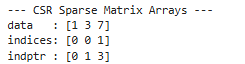
